In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
BASE_DIR = "../data"
#pls keep the data file at where yall put like in the 01 note, ty!
TRAIN_DIR = os.path.join(BASE_DIR, "Train")
VAL_DIR = os.path.join(BASE_DIR, "Validation")
TEST_DIR = os.path.join(BASE_DIR, "Test")

#i recommend going with image size 128 square and batch size 32 like many examples in class
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

#load dataset (and under the form of RGB right away too)
#we also will resize the img into IMG-_SIZE of 128 square too
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    color_mode="rgb",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    color_mode="rgb",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    color_mode="rgb",
    shuffle=False
)

#check
print(train_ds.class_names)

Found 10000 files belonging to 2 classes.
Found 800 files belonging to 2 classes.
Found 992 files belonging to 2 classes.
['WithMask', 'WithoutMask']


In [3]:
#normalize (make the RGB valuables from 0-255 range to 0-1 range)
#it's basically just a devide math, new pixel num = old num : 255
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds_nor = train_ds.map(lambda images, labels: (normalization_layer(images), labels))
val_ds_nor = val_ds.map(lambda images, labels: (normalization_layer(images), labels))
test_ds_nor = test_ds.map(lambda images, labels: (normalization_layer(images), labels))

In [4]:
#get a batch from pre-normalized set
raw_images, raw_labels = next(iter(train_ds))
#and one from normalized set
normalized_images, normalized_labels = next(iter(train_ds_nor))

print("Before normalization:")
print("Shape:", raw_images.shape)
print("Min val:", tf.reduce_min(raw_images).numpy())
print("Max val:", tf.reduce_max(raw_images).numpy())

print("\nAfter normalization:")
print("Shape:", normalized_images.shape)
print("Min val:", tf.reduce_min(normalized_images).numpy())
print("Max val:", tf.reduce_max(normalized_images).numpy())

Before normalization:
Shape: (32, 128, 128, 3)
Min val: 0.0
Max val: 255.0

After normalization:
Shape: (32, 128, 128, 3)
Min val: 0.0
Max val: 1.0


In [5]:
#augmentation (but on normalized sets)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
], name="data_augmentation")

train_ds_augmented = train_ds_nor.map(lambda x, y: (data_augmentation(x, training=True), y))

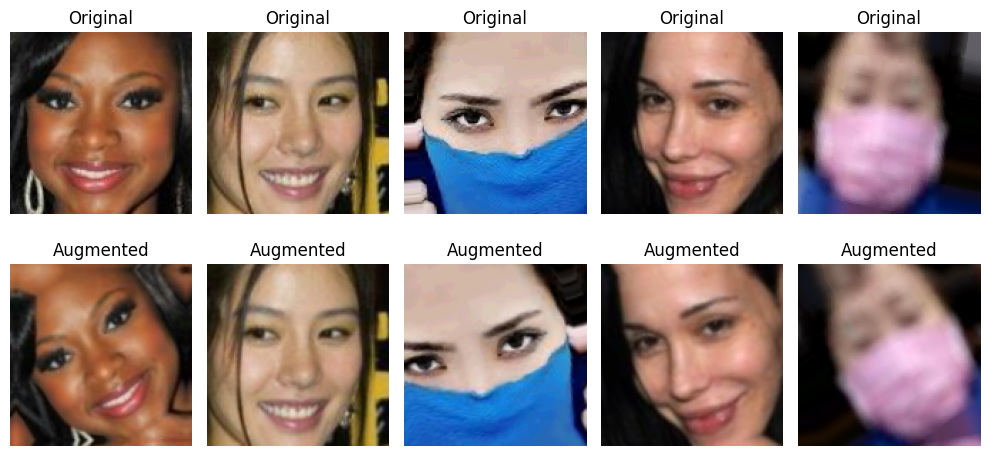

In [6]:
#check aug
images, labels = next(iter(train_ds_nor))
augmented_images = data_augmentation(
    images,
    training=True
)

plt.figure(figsize=(10, 5))

for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i])
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, 5, i + 6)
    plt.imshow(augmented_images[i])
    plt.title("Augmented")
    plt.axis("off")

plt.tight_layout()
plt.show()